In [1]:
!pip install scorecardpy

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
import pandas as pd
import numpy as np
import scorecardpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Load Data
# ----------------------------
file_path = "Final_Model_Dataset.xlsx"
df = pd.read_excel(file_path)

target = "Default_y"
X = df.drop(columns=[target])
y = df[target]


In [4]:
# Step 2: Train-Test Split
train, test = train_test_split(df, test_size=0.3, stratify=df[target], random_state=42)

# Keep the original row indices so we can tag every customer as Train/Test later
train_idx = train.index
test_idx = test.index

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (70, 27)
Test shape: (30, 27)


In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
# Step 3: WOE Binning + IV Filter

bins = sc.woebin(train, y=target)

iv_list = []
for var, df_bin in bins.items():
    iv = df_bin['total_iv'].iloc[0]
    iv_list.append((var, iv))

iv_df = pd.DataFrame(iv_list, columns=["variable", "total_iv"])

# Filter out weak variables (IV < 0.02)
good_vars = iv_df.loc[iv_df['total_iv'] > 0.02, 'variable'].tolist()
print(f"{len(good_vars)} variables kept out of {len(iv_df)}:")
print(good_vars)

# Keep only strong variables in train & test
train = train[good_vars + [target]]
test = test[good_vars + [target]]


[INFO] creating woe binning ...
Binning on 70 rows and 27 columns in 00:00:27
26 variables kept out of 26:
['Credit_Utilization_Ratio', 'Credit_Card_Utilization', 'No_of_Inquiries_12M', 'Savings_Account_Balance', 'DPD_30', 'Behavior_Spending_Score', 'Newest_Trade_Open_Months', 'Checking_Account_Balance', 'Income_INR', 'Total_Credit_Limit', 'Months_Since_Most_Recent_Delinquency', 'Loan_Tenure_Months', 'Max_Credit_Exposure', 'Outstanding_Loans', 'Credit_History_Length', 'Delinquency_12M', 'Total_Current_Balance', 'No_of_Open_Accounts', 'Loan_Amount', 'Cluster', 'No_of_Inquiries_6M', 'Worst_Current_Status', 'Behavior_Repayment_Score', 'Employment_Years', 'Oldest_Trade_Open_Months', 'No_of_Closed_Accounts']


In [8]:
# Step 3.5: Apply the WOE transform before modelling
# logistic regression to have been fit on WOE-encoded values, not raw values.
bins_good = {k: v for k, v in bins.items() if k in good_vars}

train_woe = sc.woebin_ply(train, bins_good)
test_woe  = sc.woebin_ply(test, bins_good)

X_train = train_woe.drop(columns=[target])
y_train = train_woe[target]

X_test = test_woe.drop(columns=[target])
y_test = test_woe[target]

print("X_train (WOE) shape:", X_train.shape)
print("X_test  (WOE) shape:", X_test.shape)

[INFO] converting into woe values ...
[INFO] converting into woe values ...
X_train (WOE) shape: (70, 26)
X_test  (WOE) shape: (30, 26)


In [9]:
# Step 4: Logistic Regression Model (now fit on WOE values)

model = LogisticRegression(max_iter=1000, solver="lbfgs")
model.fit(X_train, y_train)

# Predictions (probabilities)
y_pred_prob = model.predict_proba(X_test)[:, 1]

AUC: 0.4286
KS: 0.1270


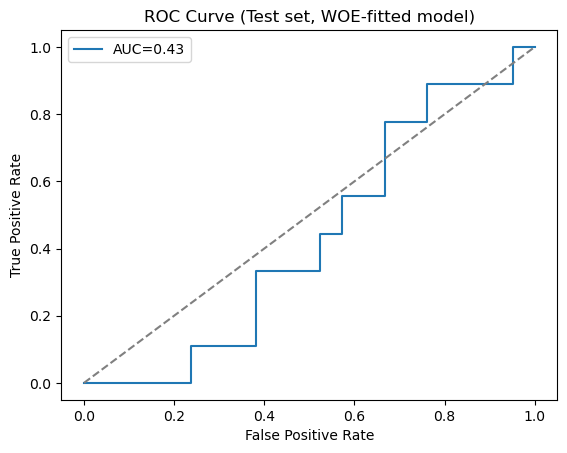

In [10]:
# Step 5: Evaluation

auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ks = max(tpr - fpr)

print(f"AUC: {auc:.4f}")
print(f"KS: {ks:.4f}")

plt.plot(fpr, tpr, label=f"AUC={auc:.2f}")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test set, WOE-fitted model)")
plt.legend()
plt.show()

In [11]:
# Step 6: Scorecard Creation

# xcolumns must be the WOE column names (scorecardpy strips the "_woe" suffix internally)
x_columns = list(X_train.columns)

card = sc.scorecard(bins_good, model, xcolumns=x_columns,
                    points0=600, odds0=35/65, pdo=50)

card_df = pd.concat({k: pd.DataFrame(v) for k, v in card.items()})

# This step assigns a credit score to each customer in the TEST dataset
test_score = sc.scorecard_ply(test, card)

output_path = "Final_Model_Scorecard_FIXED.xlsx"
with pd.ExcelWriter(output_path) as writer:
    card_df.to_excel(writer, sheet_name="Scorecard")
    test_score.to_excel(writer, sheet_name="Test_Scores", index=False)

print(f"Scorecard and test scores saved successfully at {output_path}")

Scorecard and test scores saved successfully at Final_Model_Scorecard_FIXED.xlsx


In [12]:
# Clean scorecard
card_df = pd.concat({k: pd.DataFrame(v) for k, v in card.items()})
card_df = card_df.reset_index(level=0).rename(columns={'level_0': 'Variable'})
card_df = card_df[['Variable', 'bin', 'points']]

output_path = "Final_Model_Scorecard_Clean_FIXED.xlsx"
with pd.ExcelWriter(output_path) as writer:
    card_df.to_excel(writer, sheet_name="Scorecard", index=False)
    test_score.to_excel(writer, sheet_name="Test_Scores", index=False)

print(f"Clean scorecard saved at {output_path}")


Clean scorecard saved at Final_Model_Scorecard_Clean_FIXED.xlsx


In [13]:
# ----------------------------
# Step 7 (FIXED): Score ALL customers using sc.scorecard_ply (not a hand-rolled function)
# ----------------------------
full_scores = sc.scorecard_ply(df[good_vars + [target]], card)
df_out = df.copy()
df_out["Final_Score"] = full_scores["score"]

# Tag every customer as Train or Test, based on the split done in Step 2.
# This is what lets Step 8 evaluate performance on the held-out set only.
df_out["Sample"] = "Train"
df_out.loc[test_idx, "Sample"] = "Test"

output_path = "Customer_Final_Scores_FIXED.xlsx"
df_out.to_excel(output_path, index=False)
print(f"Final scores (with Sample flag) saved to {output_path}")
print(df_out["Sample"].value_counts())


Final scores (with Sample flag) saved to Customer_Final_Scores_FIXED.xlsx
Sample
Train    70
Test     30
Name: count, dtype: int64
